# Ultra-Marathon Running
A huge collection of over 7M race records registered between 1798 and 2022

## [Link to Kaggle Dataset](https://www.kaggle.com/datasets/aiaiaidavid/the-big-dataset-of-ultra-marathon-running/data)

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jupyter_black

plt.rcParams["figure.figsize"] = (10, 6)
jupyter_black.load()

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("TWO_CENTURIES_OF_UM_RACES.csv", low_memory=False)

In [5]:
df.head()

,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2
3,2018,06.01.2018,Selva Costera (CHI),50km,22,5:34:13 h,Columbia,ARG,1976.0,M,M40,8.976,3
4,2018,06.01.2018,Selva Costera (CHI),50km,22,5:54:14 h,Baguales Trail,CHI,1992.0,M,M23,8.469,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7461195 entries, 0 to 7461194
Data columns (total 13 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Year of event              int64  
 1   Event dates                object 
 2   Event name                 object 
 3   Event distance/length      object 
 4   Event number of finishers  int64  
 5   Athlete performance        object 
 6   Athlete club               object 
 7   Athlete country            object 
 8   Athlete year of birth      float64
 9   Athlete gender             object 
 10  Athlete age category       object 
 11  Athlete average speed      object 
 12  Athlete ID                 int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 740.0+ MB


In [5]:
df["Event distance/length"].value_counts()

Event distance/length
50km              1522609
100km              951742
50mi               352181
56km               333253
87km               212062
                   ...   
61.15km                 1
27:30h                  1
178km/2Etappen          1
740km                   1
158.5mi                 1
Name: count, Length: 2159, dtype: int64

In [3]:
# Filter the DataFrame for the year 2022
df_2022 = df[df["Year of event"] == 2022]

# Check the events that happened most frequently
df_2022["Event distance/length"].value_counts()

Event distance/length
50km               91699
100km              42654
50mi               19551
45km               14968
100mi              13857
                   ...  
79mi                   1
860mi/17Etappen        1
82.8km                 1
48.0km                 1
27:30h                 1
Name: count, Length: 719, dtype: int64

### Filter the Data

In [30]:
filtered_df = df[
    (df["Event distance/length"].isin(["50km", "100km"]))
    & (df["Year of event"] == 2022)
    & (df["Event name"].str.contains("USA", case=False, na=False))
].copy()

In [31]:
filtered_df.shape

(50964, 13)

## Data Cleaning

In [32]:
(filtered_df.isnull().sum().sort_values(ascending=False) / len(filtered_df)) * 100

Athlete club                 15.716977
Athlete age category          3.265050
Athlete year of birth         3.261126
Year of event                 0.000000
Event dates                   0.000000
Event name                    0.000000
Event distance/length         0.000000
Event number of finishers     0.000000
Athlete performance           0.000000
Athlete country               0.000000
Athlete gender                0.000000
Athlete average speed         0.000000
Athlete ID                    0.000000
dtype: float64

In [33]:
# Drop rows with NaN values in 'Athlete year of birth'
filtered_df = filtered_df.dropna(subset=["Athlete year of birth"])

# Convert 'Athlete year of birth' to integers
filtered_df["Athlete year of birth"] = filtered_df["Athlete year of birth"].astype(int)

In [34]:
# Remove 'USA' from the 'Event name' column
filtered_df["Event name"] = filtered_df["Event name"].str.replace(
    "(USA)", "", case=False
)

In [35]:
# Removing the 'h' from the Athlete performance
filtered_df["Athlete performance"] = (
    filtered_df["Athlete performance"].str.split(" ").str.get(0)
)

In [36]:
# Create column with the age of the athletes
filtered_df["Athlete age"] = (
    filtered_df["Year of event"] - filtered_df["Athlete year of birth"]
)

In [37]:
filtered_df["Athlete average speed"] = filtered_df["Athlete average speed"].astype(
    "float64"
)

### Drop Columns

As most of the values in the 'Athlete club' are null so there is no use of this column

In [38]:
filtered_df.columns

Index(['Year of event', 'Event dates', 'Event name', 'Event distance/length',
       'Event number of finishers', 'Athlete performance', 'Athlete club',
       'Athlete country', 'Athlete year of birth', 'Athlete gender',
       'Athlete age category', 'Athlete average speed', 'Athlete ID',
       'Athlete age'],
      dtype='object')

In [39]:
filtered_df = filtered_df.drop(
    [
        "Year of event",
        "Athlete age category",
        "Athlete year of birth",
        "Athlete club",
        "Athlete country",
    ],
    axis=1,
)

In [40]:
# Check for duplicate rows
filtered_df.duplicated().sum()

0

In [41]:
filtered_df.dtypes

Event dates                   object
Event name                    object
Event distance/length         object
Event number of finishers      int64
Athlete performance           object
Athlete gender                object
Athlete average speed        float64
Athlete ID                     int64
Athlete age                    int64
dtype: object

In [42]:
filtered_df.head()

,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete gender,Athlete average speed,Athlete ID,Athlete age
3138257,12.03.2022,Griffith Park Trail Marathon,50km,76,4:01:13,M,12.437,202038,50
3138258,12.03.2022,Griffith Park Trail Marathon,50km,76,4:04:07,M,12.289,55422,59
3138259,12.03.2022,Griffith Park Trail Marathon,50km,76,4:27:18,M,11.223,655829,42
3138260,12.03.2022,Griffith Park Trail Marathon,50km,76,4:28:32,M,11.172,596371,22
3138261,12.03.2022,Griffith Park Trail Marathon,50km,76,4:40:49,M,10.683,361178,41


In [43]:
# Rename and reorder columns
df2 = filtered_df.rename(
    columns={
        "Event dates": "race_day",
        "Event name": "race_name",
        "Event distance/length": "race_length",
        "Event number of finishers": "race_number_of_finishers",
        "Athlete ID": "athlete_id",
        "Athlete gender": "athlete_sex",
        "Athlete age": "athlete_age",
        "Athlete performance": "athlete_performance",
        "Athlete average speed": "athlete_average_speed",
    }
).copy()

In [44]:
df2.head()

,race_day,race_name,race_length,race_number_of_finishers,athlete_performance,athlete_sex,athlete_average_speed,athlete_id,athlete_age
3138257,12.03.2022,Griffith Park Trail Marathon,50km,76,4:01:13,M,12.437,202038,50
3138258,12.03.2022,Griffith Park Trail Marathon,50km,76,4:04:07,M,12.289,55422,59
3138259,12.03.2022,Griffith Park Trail Marathon,50km,76,4:27:18,M,11.223,655829,42
3138260,12.03.2022,Griffith Park Trail Marathon,50km,76,4:28:32,M,11.172,596371,22
3138261,12.03.2022,Griffith Park Trail Marathon,50km,76,4:40:49,M,10.683,361178,41


In [45]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49302 entries, 3138257 to 3609632
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   race_day                  49302 non-null  object 
 1   race_name                 49302 non-null  object 
 2   race_length               49302 non-null  object 
 3   race_number_of_finishers  49302 non-null  int64  
 4   athlete_performance       49302 non-null  object 
 5   athlete_sex               49302 non-null  object 
 6   athlete_average_speed     49302 non-null  float64
 7   athlete_id                49302 non-null  int64  
 8   athlete_age               49302 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.8+ MB


## Data Visualization

In [46]:
df2.athlete_sex.value_counts()

athlete_sex
M    32417
F    16882
X        3
Name: count, dtype: int64

In [47]:
# Drop rows where athlete_sex is 'X'
df2 = df2[df2["athlete_sex"] != "X"]

### Male and Female Performance

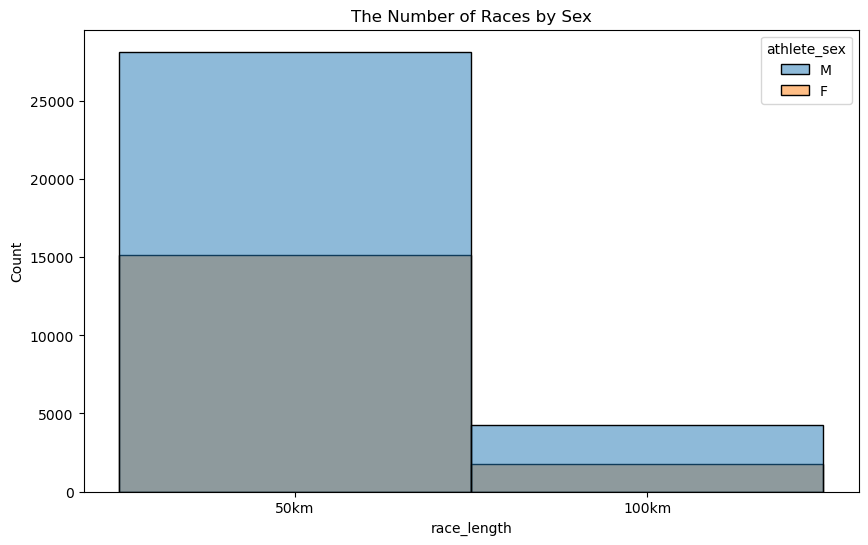

In [48]:
sns.histplot(data=df2, x="race_length", hue="athlete_sex")
plt.title("The Number of Races by Sex")
plt.show()

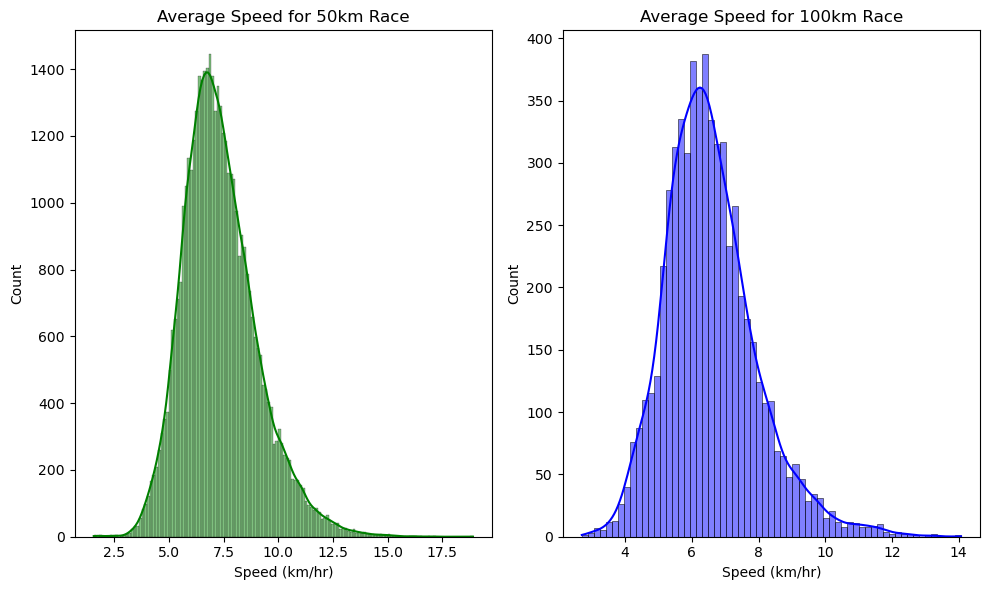

In [98]:
# Create subplots
fig, axes = plt.subplots(1, 2)

# Plot for 50km race
sns.histplot(
    df2[df2["race_length"] == "50km"]["athlete_average_speed"],
    kde=True,
    color="green",
    ax=axes[0],
)
axes[0].set_xlabel("Speed (km/hr)")
axes[0].set_title("Average Speed for 50km Race")

# Plot for 100km race
sns.histplot(
    df2[df2["race_length"] == "100km"]["athlete_average_speed"],
    kde=True,
    color="blue",
    ax=axes[1],
)
axes[1].set_xlabel("Speed (km/hr)")
axes[1].set_title("Average Speed for 100km Race")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

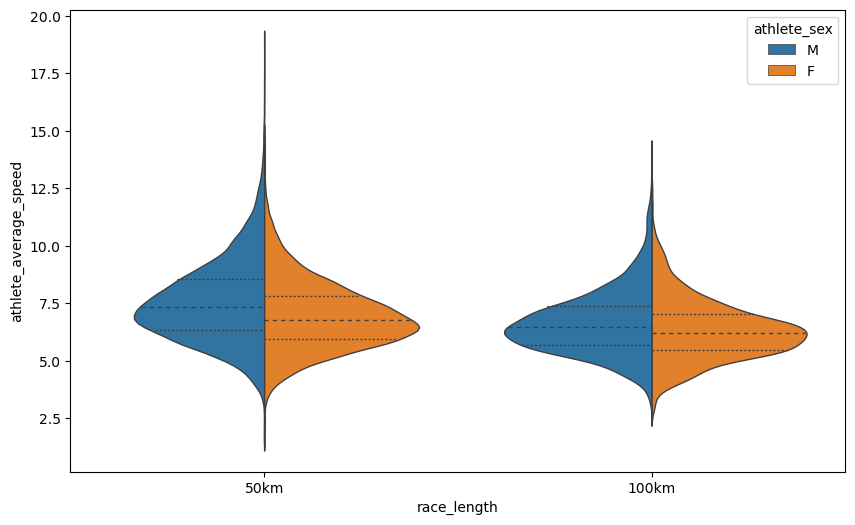

In [99]:
sns.violinplot(
    data=df2,
    x="race_length",
    y="athlete_average_speed",
    hue="athlete_sex",
    split=True,
    inner="quartz",
    linewidth=1,
)
plt.show()

### Performance Time

In [52]:
df2.athlete_performance.value_counts()

athlete_performance
7:58:00     17
6:38:00     14
7:24:00     14
7:11:00     13
6:31:00     13
            ..
10:56:18     1
11:06:18     1
11:10:49     1
11:13:33     1
7:25:57      1
Name: count, Length: 24021, dtype: int64

In [89]:
df2["athlete_performance"].sample(20)

3447844    18:52:49
3601742     6:39:45
3160861     6:24:16
3319968     6:31:41
3436401    16:56:02
3187075    14:40:16
3188135     7:25:18
3572622    19:18:38
3546089     6:22:31
3545969     7:55:05
3167540    16:41:30
3445047     4:28:18
3546110     3:24:10
3487576     6:46:38
3162365     6:45:49
3168898     4:51:48
3440923     5:36:11
3229629     8:38:33
3405693    10:12:35
3209468     6:35:35
Name: athlete_performance, dtype: object

In [80]:
# Check for values exceeding 24 hours
df2[pd.to_timedelta(df2["athlete_performance"]) > pd.Timedelta(days=1)].shape[0]

125

In [81]:
len(df2.athlete_performance)

49299

In [90]:
df2["athlete_performance"] = pd.to_datetime(
    df2["athlete_performance"], format="mixed", errors="coerce"
)

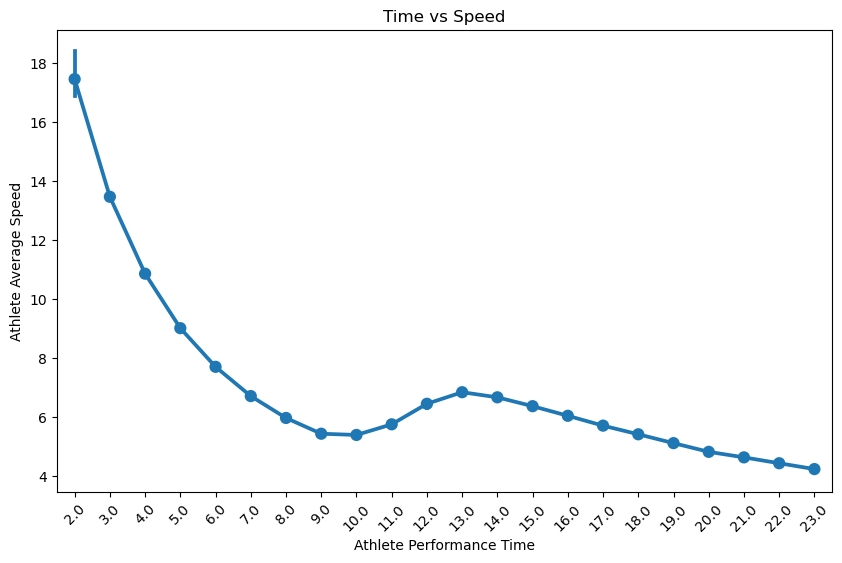

In [91]:
sns.pointplot(
    data=df2["athlete_performance"],
    x=df2["athlete_performance"].dt.hour,
    y=df2["athlete_average_speed"],
    estimator="mean",
)
plt.title("Time vs Speed")
plt.xlabel("Athlete Performance Time")
plt.ylabel("Athlete Average Speed")
plt.xticks(rotation=45)
plt.show()

In [100]:
df2["performance_in_hours"] = df2["athlete_performance"].dt.hour + (
    df2["athlete_performance"].dt.minute / 60
)

### Performance per Races

In [101]:
races_by_hours = (
    df2.groupby("race_name")["performance_in_hours"]
    .agg(["mean", "count"])
    .query("count > 19")
)
races_by_hours.head()

,mean,count
race_name,,
AZT Oracle Rumble 50 Km,7.762745,51
Above the Clouds Ultra,7.178049,41
Afton Trail Run 50K,6.243302,214
Algonquin 50km Trail Race,6.680667,200
Ancient Lakes 50 km Trail Run,7.521073,87


In [103]:
longest_races_time = races_by_hours.sort_values(by="mean", ascending=False)

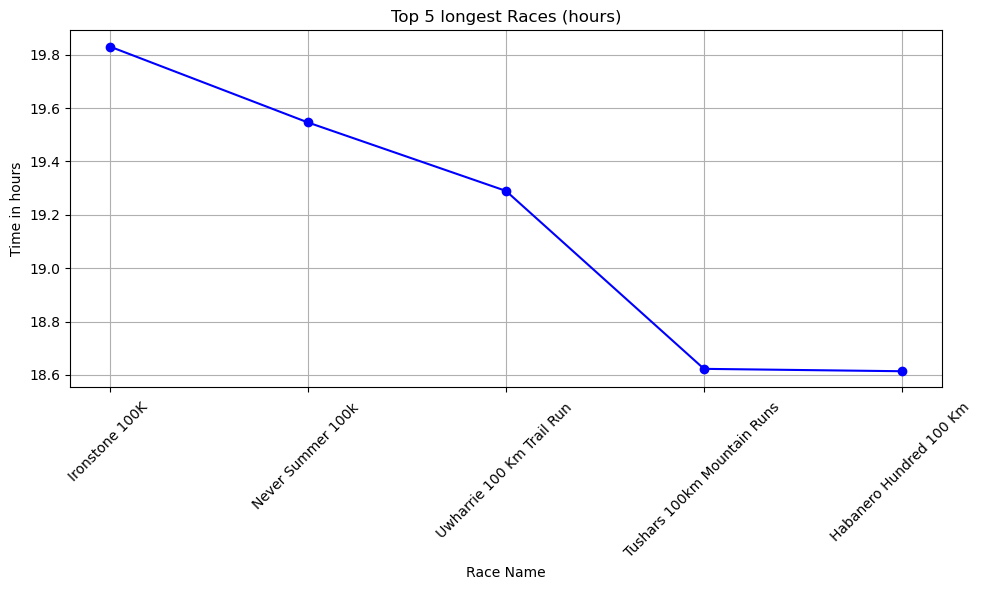

In [104]:
plt.plot(
    longest_races_time.head().index,
    longest_races_time.head()["mean"],
    marker="o",
    color="b",
    linestyle="-",
)
plt.xlabel("Race Name")
plt.ylabel("Time in hours")
plt.title("Top 5 longest Races (hours)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### What ia a good age for Ultra-Marathons?

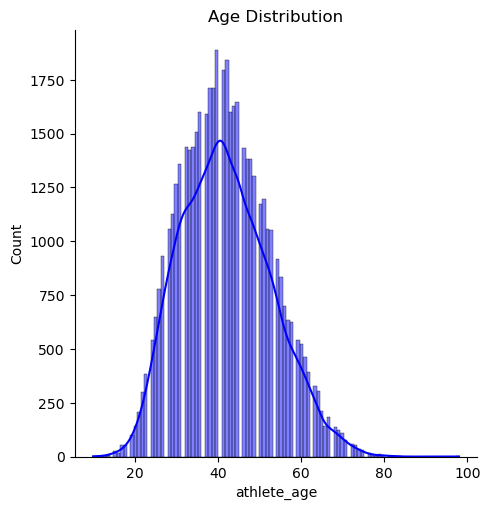

In [105]:
sns.displot(data=df2, x="athlete_age", kind="hist", color="blue", kde="True")
plt.title("Age Distribution")
plt.show()

In [106]:
df2.race_length.value_counts()

race_length
50km     43254
100km     6045
Name: count, dtype: int64

In [107]:
age_vs_speed = (
    df2.query('race_length == "100km"')
    .groupby("athlete_age")["athlete_average_speed"]
    .agg(["mean", "count"])
    .sort_values(by="mean", ascending=False)
    .query("count > 19")
    .head(20)
)

In [108]:
age_vs_speed

,mean,count
athlete_age,,
31,7.252680,172
27,7.231690,100
30,7.108454,130
28,7.106789,128
22,7.096875,24
25,7.051301,73
24,6.997961,51
32,6.978462,173
34,6.973720,168


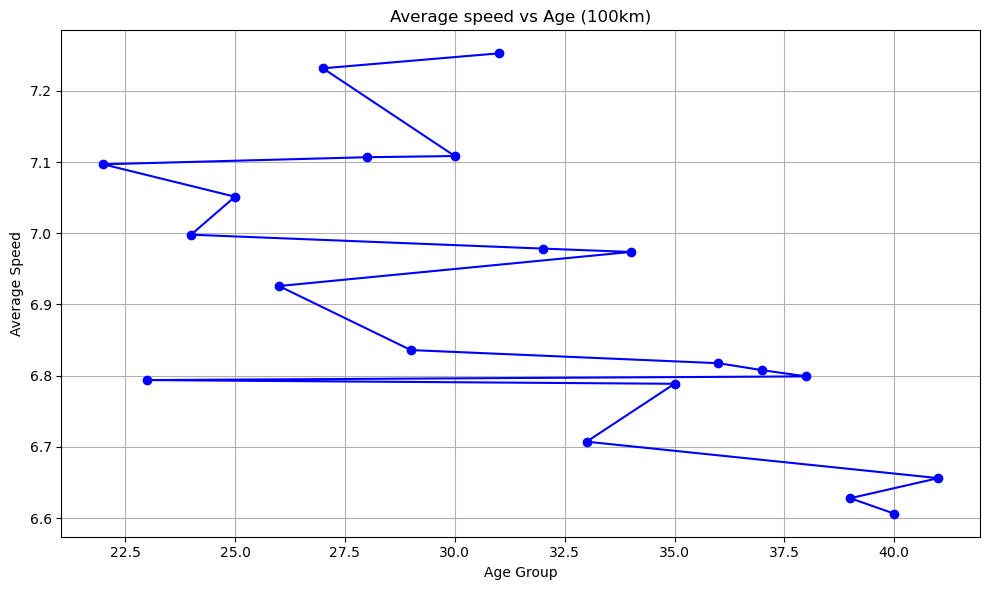

In [143]:
plt.plot(age_vs_speed.index, age_vs_speed["mean"], marker="o", color="b", linestyle="-")
plt.xlabel("Age Group")
plt.ylabel("Average Speed")
plt.title("Average speed vs Age (100km)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Does the season has any effect?

**USA season**:
- Winter: December (12), January (1), February (2)
- Spring: March (3), April (4), May (5)
- Summer: June (6), July (7), August (8)
- Fall: September (9), October (10), November (11)

In [140]:
df2["race_day"].iloc[0]

'12.03'

In [110]:
df2["race_month"] = df2["race_day"].str.split(".").str.get(1).astype(int)

In [111]:
def classify_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    elif month in [9, 10, 11]:
        return "fall"

In [112]:
# Apply classify_season to create the 'season' column
df2["season"] = df2["race_month"].apply(classify_season)

In [113]:
df2.season.value_counts()

season
spring    14831
fall      13456
summer     9640
winter     8399
Name: count, dtype: int64

In [114]:
# We'll remove '.2022' from 'race_day' column
df2["race_day"] = df2["race_day"].str.replace(".2022", "")

In [115]:
df2.head()

,race_day,race_name,race_length,race_number_of_finishers,athlete_performance,athlete_sex,athlete_average_speed,athlete_id,athlete_age,performance_in_hours,race_month,season
3138257,12.03,Griffith Park Trail Marathon,50km,76,2024-07-13 04:01:13,M,12.437,202038,50,4.016667,3,spring
3138258,12.03,Griffith Park Trail Marathon,50km,76,2024-07-13 04:04:07,M,12.289,55422,59,4.066667,3,spring
3138259,12.03,Griffith Park Trail Marathon,50km,76,2024-07-13 04:27:18,M,11.223,655829,42,4.450000,3,spring
3138260,12.03,Griffith Park Trail Marathon,50km,76,2024-07-13 04:28:32,M,11.172,596371,22,4.466667,3,spring
3138261,12.03,Griffith Park Trail Marathon,50km,76,2024-07-13 04:40:49,M,10.683,361178,41,4.666667,3,spring


In [122]:
# Comparing the average speed by season and sex
df2.query('race_length == "50km"').groupby(["season", "athlete_sex"]).agg(
    {"athlete_sex": "count", "athlete_average_speed": "mean"}
)

athlete_sex  athlete_average_speed
season athlete_sex                                    
fall   F                   4355               6.936042
       M                   8619               7.465247
spring F                   4711               6.975763
       M                   8380               7.585603
summer F                   3056               6.787149
       M                   5509               7.269333
winter F                   2408               7.374272
       M                   4913               8.050073

In [119]:
# Aggregate the data
agg_data = (
    df2.query('race_length == "50km"')
    .groupby(["season", "athlete_sex"])
    .agg(
        athlete_sex_count=("athlete_sex", "count"),
        athlete_average_speed_mean=("athlete_average_speed", "mean"),
    )
    .reset_index()
)

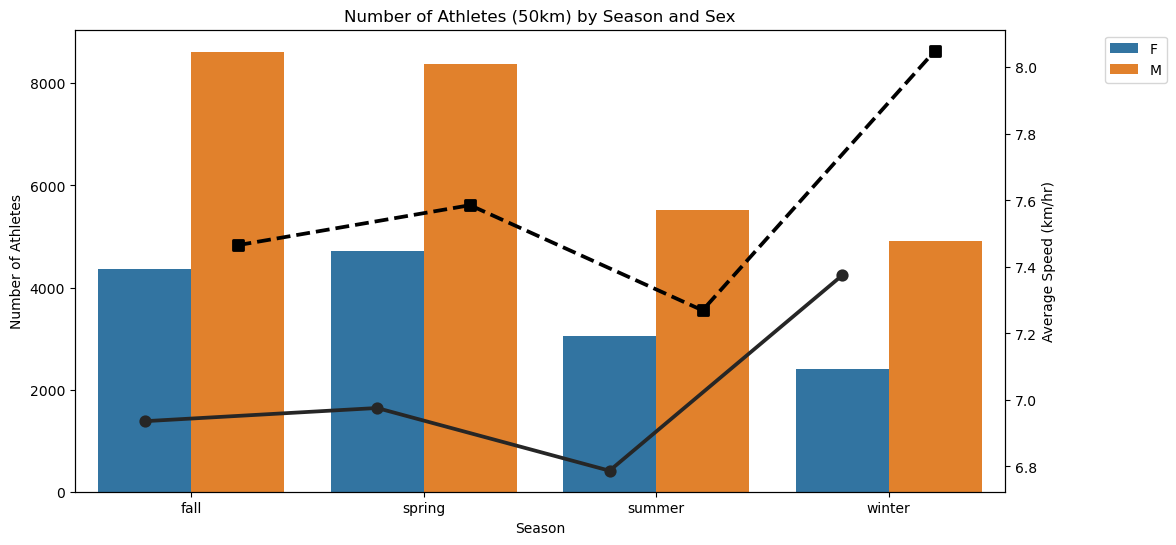

In [125]:
# Create subplots
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the count of athletes
sns.barplot(data=agg_data, x="season", y="athlete_sex_count", hue="athlete_sex", ax=ax1)
ax1.set_title("Number of Athletes (50km) by Season and Sex")
ax1.set_xlabel("Season")
ax1.set_ylabel("Number of Athletes")

# Create another axis for the average speed
ax2 = ax1.twinx()

# Plot the average speed
sns.pointplot(
    data=agg_data,
    x="season",
    y="athlete_average_speed_mean",
    hue="athlete_sex",
    markers=["o", "s"],
    color="black",
    linestyles=["-", "--"],
    dodge=0.4,
    ax=ax2,
)
ax2.set_ylabel("Average Speed (km/hr)")

# Adjust the legend to avoid overlap
ax1.legend(loc="upper left", bbox_to_anchor=(1.1, 1.0))
ax2.legend().set_visible(False)

plt.show()

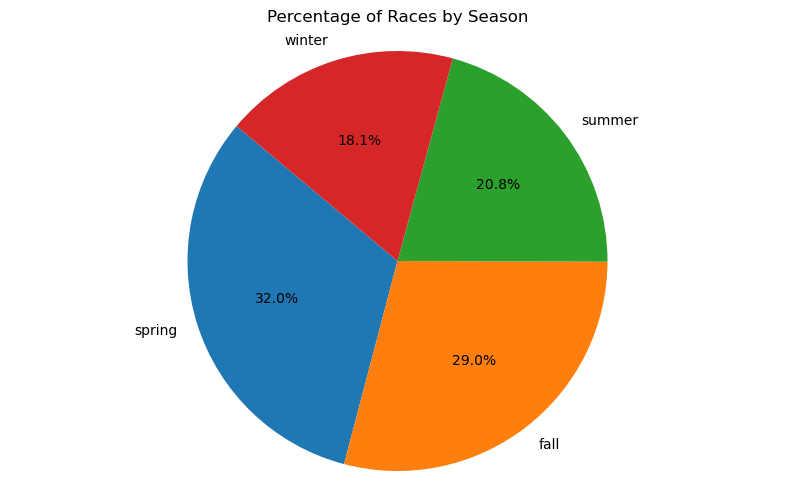

In [130]:
# Group by season and count races
season_counts = df2["season"].value_counts()

plt.pie(season_counts, labels=season_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Percentage of Races by Season")
plt.axis("equal")
plt.show()